<a href="https://colab.research.google.com/github/meta-llama/llama-recipes/blob/main/recipes/use_cases/agents/langchain/tool-calling-agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install -U langchain_groq langchain tavily-python replicate

# Tool calling agent with Llama 3

[Tool calling](https://python.langchain.com/docs/modules/agents/agent_types/tool_calling/) allows an LLM to detect when one or more tools should be called.

It will then respond with the inputs that should be passed to those tools. 

LangChain has a general agent that works with tool-calling LLMs. In this notebook we'll use the following tools with Agent Executor:



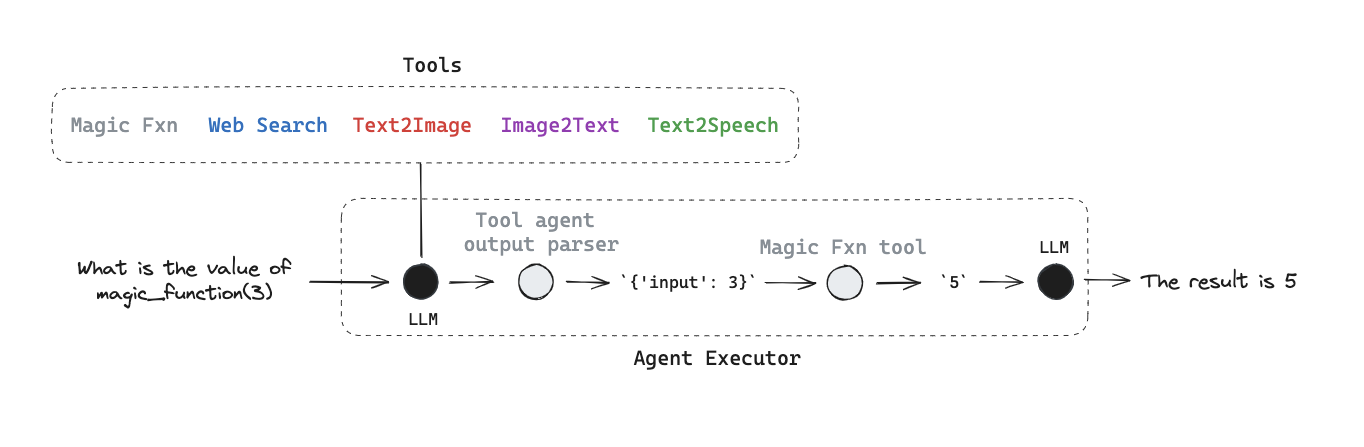

## Tools

### 1. Custom Function

We'll define a few tools that our agent will use.

In [ ]:
def magic_function(input: int) -> int:
    """Applies a magic function to an input."""
    return input + 2

magic_function(3)

In [ ]:
from langchain.agents import tool

@tool
def magic_function(input: int) -> int:
    """Applies a magic function to an input."""
    return input + 2

### 2. Web Search

Let's use [Tavily](https://tavily.com/#api) for web search.

In [ ]:
# Ensure API key is set
import os
from getpass import getpass
TAVILY_API_KEY = getpass()
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults()

### 3. Text-2-Image

We'll use Replicate, which [hosts an open DALL-E model](https://replicate.com/lucataco/open-dalle-v1.1/versions/1c7d4c8dec39c7306df7794b28419078cb9d18b9213ab1c21fdc46a1deca0144).

Test the code before converting it to a tool (this may take 1-2 minutes to run):

In [ ]:
# Ensure API key is set
REPLICATE_API_TOKEN = getpass()
os.environ["REPLICATE_API_TOKEN"] = REPLICATE_API_TOKEN

In [ ]:
import replicate
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def display_image(image_url):
    """Display generated image"""
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content))  
    plt.imshow(img)
    plt.axis('off')
    plt.show()

def text2image(text: str) -> str:
    """generate an image based on a text."""
    output = replicate.run(
        "lucataco/open-dalle-v1.1:1c7d4c8dec39c7306df7794b28419078cb9d18b9213ab1c21fdc46a1deca0144",
        input={
            "width": 1024,
            "height": 1024,
            "prompt": text, #"a yellow lab puppy running free with wild flowers in the mountain behind",
            "scheduler": "KarrasDPM",
            "num_outputs": 1,
            "guidance_scale": 7.5,
            "apply_watermark": True,
            "negative_prompt": "worst quality, low quality",
            "prompt_strength": 0.8,
            "num_inference_steps": 60
        }
    )
    print(output)
    return output[0]

output = text2image("a yellow lab puppy running free with wild flowers in the mountain behind")
display_image(output)

Wrap the code above as a custom tool:

In [ ]:
from langchain.agents import tool

@tool
def text2image(text: str) -> int:
    """generate an image based on a text."""    
    output = replicate.run(
        "lucataco/open-dalle-v1.1:1c7d4c8dec39c7306df7794b28419078cb9d18b9213ab1c21fdc46a1deca0144",
        input={
            "width": 1024,
            "height": 1024,
            "prompt": text, #"a yellow lab puppy running free with wild flowers in the mountain behind",
            "scheduler": "KarrasDPM",
            "num_outputs": 1,
            "guidance_scale": 7.5,
            "apply_watermark": True,
            "negative_prompt": "worst quality, low quality",
            "prompt_strength": 0.8,
            "num_inference_steps": 60
        }
    )
    print(output)
    return output[0]

### 4. Image-2-Text

We'll use Replicate, which [hosts llava-13b](https://replicate.com/yorickvp/llava-13b).

Test the code before converting it to a tool:

In [ ]:
def image2text(image_url: str, prompt: str) -> int:
    """generate a text on image_url based on prompt."""
    input = {
        "image": image_url,
        "prompt": prompt
    }

    output = replicate.run(
        "yorickvp/llava-13b:b5f6212d032508382d61ff00469ddda3e32fd8a0e75dc39d8a4191bb742157fb",
        input=input
    )

    return "".join(output)

text = image2text(output, "tell me a bedtime story about the image")
text

Wrap the code above as another custom tool:

In [ ]:
from langchain.agents import tool

@tool
def image2text(image_url: str, prompt: str) -> int:
    """generate a text on image_url based on prompt."""    
    input = {
        "image": image_url,
        "prompt": prompt
    }

    output = replicate.run(
        "yorickvp/llava-13b:b5f6212d032508382d61ff00469ddda3e32fd8a0e75dc39d8a4191bb742157fb",
        input=input
    )

    return "".join(output)

### 5. Text-2-Speech

We'll use Replicate, which [hosts text-2-speech](https://replicate.com/cjwbw/seamless_communication).

Test the code before creating yet another custom tool (this may take a couple of minutes to run):

In [ ]:
from IPython.display import Audio

def play_audio(output_url):
    return Audio(url=output_url, autoplay=False)

def text2speech(text: str) -> int:
    """convert a text to a speech."""
    output = replicate.run(
        "cjwbw/seamless_communication:668a4fec05a887143e5fe8d45df25ec4c794dd43169b9a11562309b2d45873b0",
        input={
            "task_name": "T2ST (Text to Speech translation)",
            "input_text": text,
            "input_text_language": "English",
            "max_input_audio_length": 60,
            "target_language_text_only": "English",
            "target_language_with_speech": "English"
        }
    )
    return output['audio_output']

output_url = text2speech(text)
play_audio(output_url)

Wrap the code above to a new custom tool:

In [ ]:
from langchain.agents import tool

@tool
def text2speech(text: str) -> int:
    """convert a text to a speech."""    
    output = replicate.run(
        "cjwbw/seamless_communication:668a4fec05a887143e5fe8d45df25ec4c794dd43169b9a11562309b2d45873b0",
        input={
            "task_name": "T2ST (Text to Speech translation)",
            "input_text": text,
            "input_text_language": "English",
            "max_input_audio_length": 60,
            "target_language_text_only": "English",
            "target_language_with_speech": "English"
        }
    )
    return output['audio_output']

Collect all tools created to a list:

In [ ]:
tools = [magic_function, web_search_tool, text2image, image2text, text2speech]

tools

## LLM

Here, we need a Llama 3 model that supports tool use.

This can be accomplished via prompt engineering (e.g., see [here](https://replicate.com/hamelsmu/llama-3-70b-instruct-awq-with-tools)) or fine-tuning (e.g., see [here](https://huggingface.co/mzbac/llama-3-8B-Instruct-function-calling) and [here](https://huggingface.co/mzbac/llama-3-8B-Instruct-function-calling)).

We can review LLMs that support tool calling [here](https://python.langchain.com/docs/integrations/chat/) and Groq is included.

[Here](https://github.com/groq/groq-api-cookbook/blob/main/llama3-stock-market-function-calling/llama3-stock-market-function-calling.ipynb) is a notebook by Groq on function calling with Llama 3 and LangChain.

In [ ]:
GROQ_API_KEY = getpass()

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(temperature=0, model="llama3-70b-8192")

## Agent

We use LangChain [tool calling agent](https://python.langchain.com/docs/modules/agents/agent_types/tool_calling/). 

In [ ]:
# Prompt 
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant"),
        ("human", "{input}"),
        MessagesPlaceholder("agent_scratchpad"),
    ]
)
prompt.pretty_print()

In [ ]:
# create an agent using the llm, tools and prompt created above
from langchain.agents import AgentExecutor, create_tool_calling_agent, tool
agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, return_intermediate_steps=True)

In [ ]:
# this will invoke the magic_function tool
agent_executor.invoke({"input": "what is the value of magic_function(3)?"})

Note that the `ToolAgentAction` in the returned `intermediate_steps` shows the tool called with input.

In [ ]:
# this will invoke the tavily_search_results_json tool
agent_executor.invoke({"input": "whats the weather in sf?"})

In [ ]:
# this will invoke the text2image tool
output = agent_executor.invoke({"input": "generate an image based on this text: a yellow lab puppy running free with wild flowers in the mountain behind"})

In [ ]:
output, output['intermediate_steps'][0][-1]

In [ ]:
image_url = output['intermediate_steps'][0][-1]
display_image(image_url)

In [ ]:
# this will invoke the image2text tool
output = agent_executor.invoke({"input": f"convert this image url to a bedtime story: {image_url}"})

In [ ]:
output, output['intermediate_steps'][0][-1]

In [ ]:
# this will invoke the text2speech tool
story = output['intermediate_steps'][0][-1]
output = agent_executor.invoke({"input": f"convert the text to speech: {story}"})

In [ ]:
output, output['intermediate_steps'][0][-1]

In [ ]:
Audio(url=output['intermediate_steps'][0][-1], autoplay=False)

We can see that the agent correctly decides which tool to call for different query using AgentExecutor. 

In the next [notebook](langgraph-agent.ipynb), we will show an alternative way to implement this agent using LangGraph.